In [1]:
from T4setup import *
from plot_functions import *
from functions import *
import random 
random.seed(10)
ped_str = ['LR', 'RL', 'AP', 'PA']
t2w_fn = 'subj2_Philips_s0_T2W_fatsat_midsag_acpc.nii'

FigureFolder = 'C:/Users/thaias/OneDrive - National Institutes of Health/FiguresOfSimulation'
DataFolder = 'C:/Users/thaias/OneDrive - National Institutes of Health/T2W_ghost_simulation/SimulationData'
s_id = 90
data = np.fliplr(nib.load(t2w_fn).get_fdata()[...,s_id].T)
myPlot = PlotSettup(block_show=False, fig_size=(7,5), save_folder=FigureFolder, overwrite_all=False)
myPlot.create_save_folder()
mySubject = ScanSetup(2,0)

mask = np.fliplr(nib.load('mask_mask.nii').get_fdata()[..., s_id].T)
def save_figure(fig, figure_name, overwrite = False):
    fig_fn = os.path.join(myPlot.save_folder, '{}.png'.format(figure_name))

    if os.path.exists(fig_fn):
        if not overwrite:
            prt_cyan('Exist image: {}'.format(fig_fn))
            return fig_fn
    prt_yellow('SAVING image to {}'.format(fig_fn))
    fig.savefig(fig_fn, bbox_inches='tight',transparent=True, pad_inches=0)
    return fig_fn
    
def save_individual_imgs(arrs, labels,title_tag= '', figsize = (5,5), overwrite = False):
    if len(arrs.shape)>2:
        for i in range(arrs.shape[-1]):
            fig, axs = plt.subplots(1,1, figsize= figsize)
            axs.imshow(arrs[...,i])
            axs.axis('off')
            axs.set_title(labels[i],**csfont)
            save_figure(fig, 'individual_fig_{}_{}.png'.format(labels[i], title_tag), overwrite)
            plt.close(fig)
    else:
        fig, axs = plt.subplots(1,1, figsize= figsize)
        axs.imshow(arrs)
        axs.axis('off')
        axs.set_title(labels,**csfont)
        save_figure(fig, 'individual_fig_{}_{}.png'.format(labels[i], title_tag), overwrite)        
        plt.close(fig)



In [2]:
# REGENERATE THE Image with Ghost artifact at different phi. 

phi_values = np.array([0.5,0.5,0.5,0.5])*np.pi
prt_green(phi_values)
R_factor = 1 # 1, or 2
if R_factor == 1:
    imgghost_func = generate_N2ghosted_arr_withADD
    ghost_func = generate_N2_ghost
if R_factor == 2:
    imgghost_func = generate_N4ghosted_arr_withADD
    ghost_func = generate_N4_ghost
    phi_values = phi_values
    
A = imgghost_func(data, 0, phi_values[0])
P = imgghost_func(data, 0, -phi_values[1])
L = imgghost_func(data, 1, phi_values[2])
R = imgghost_func(data, 1, -phi_values[3])

APLR_N = np.squeeze(np.stack([L,R,A,P], axis = -1))
k_ghost = 0.5
As_prime = ghost_func(A, 0, k_ghost)
Ps_prime = ghost_func(P, 0, k_ghost)

Ls_prime = ghost_func(L, 1, k_ghost)
Rs_prime = ghost_func(R, 1, k_ghost)

As = ghost_func(data, 0, phi_values[0])
Ps = ghost_func(data, 0, -phi_values[1])
Ls = ghost_func(data, 1, phi_values[2])
Rs = ghost_func(data, 1, -phi_values[3])

APLR_Ns = np.squeeze(np.stack([Ls,Rs,As,Ps],axis = -1))
APLR_N_prime = np.squeeze(np.stack([Ls_prime,Rs_prime,As_prime,Ps_prime],axis = -1))


APLR_Ns_Otsu = otsu_threshold_3D(APLR_Ns)
APLR_Ns_prime_Otsu = otsu_threshold_3D(APLR_N_prime)

vba_imgs  = compute_vba_arr(APLR_N, wd_size=3)

print(np.max(APLR_N), np.max(data))
# print(np.max(APLR_N), np.max(APLR_Ns/APLR_Ns))



 [1.57079633 1.57079633 1.57079633 1.57079633]
40511.16847977212 40162.95703125


 Exist image: C:/Users/thaias/OneDrive - National Institutes of Health/FiguresOfSimulation\Reference_Image.png


'C:/Users/thaias/OneDrive - National Institutes of Health/FiguresOfSimulation\\Reference_Image.png'

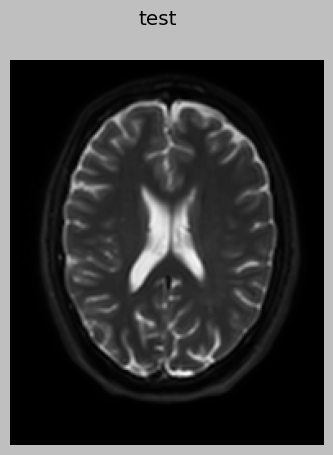

In [3]:
f = myPlot.show_imgs_array(data, 'Groundtruth', 'test')
save_figure(f, 'Reference_Image')

 Exist image: C:/Users/thaias/OneDrive - National Institutes of Health/FiguresOfSimulation\individual_fig_LR_GhostImage1.png.png
 Exist image: C:/Users/thaias/OneDrive - National Institutes of Health/FiguresOfSimulation\individual_fig_RL_GhostImage1.png.png
 Exist image: C:/Users/thaias/OneDrive - National Institutes of Health/FiguresOfSimulation\individual_fig_AP_GhostImage1.png.png
 Exist image: C:/Users/thaias/OneDrive - National Institutes of Health/FiguresOfSimulation\individual_fig_PA_GhostImage1.png.png
 Exist image: C:/Users/thaias/OneDrive - National Institutes of Health/FiguresOfSimulation\Actual Ghost at R1.png
 Exist image: C:/Users/thaias/OneDrive - National Institutes of Health/FiguresOfSimulation\individual_fig_LR_ActualGhostatR1.png.png
 Exist image: C:/Users/thaias/OneDrive - National Institutes of Health/FiguresOfSimulation\individual_fig_RL_ActualGhostatR1.png.png
 Exist image: C:/Users/thaias/OneDrive - National Institutes of Health/FiguresOfSimulation\individual_fi

'C:/Users/thaias/OneDrive - National Institutes of Health/FiguresOfSimulation\\Synthetic Ghost Masked_bm_R1.png'

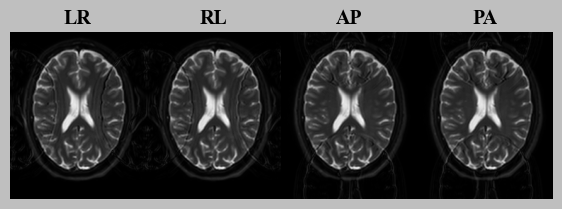

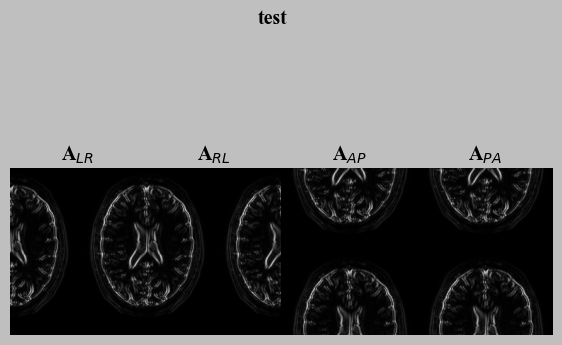

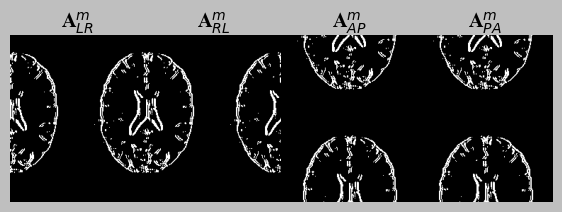

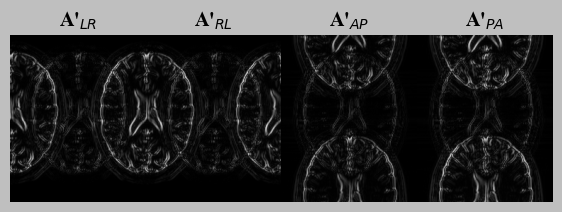

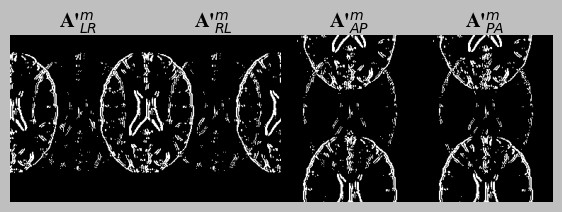

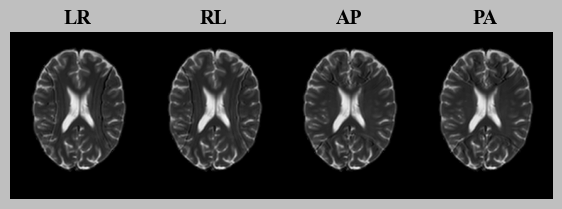

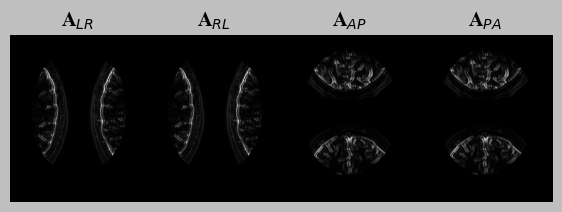

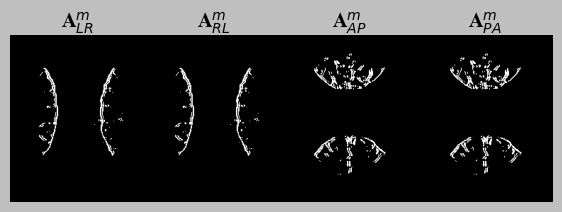

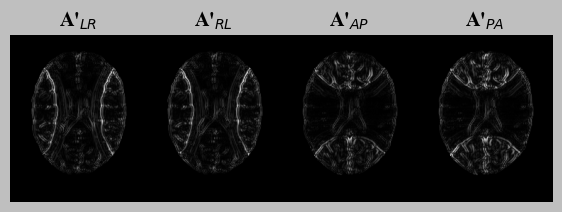

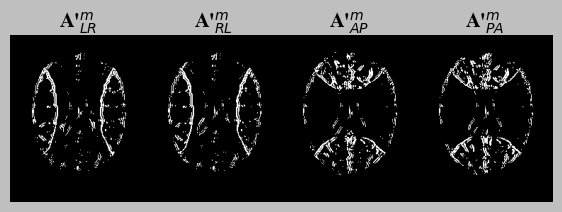

In [5]:
f = myPlot.show_imgs_array(APLR_N, list_of_names=['LR', 'RL', 'AP', 'PA'])
# myPlot.save_figure(f, 'GhostedImages')
save_individual_imgs(APLR_N, labels = ['LR', 'RL', 'AP', 'PA'], title_tag= f'GhostImage{R_factor}')
f = myPlot.show_imgs_array(APLR_Ns, list_of_names=['A$_{LR}$', 'A$_{RL}$', 'A$_{AP}$', 'A$_{PA}$'], main_title='test')
myPlot.save_figure(f, f'Actual Ghost at R{R_factor}')
save_individual_imgs(APLR_Ns, labels = ['LR', 'RL', 'AP', 'PA'], title_tag= f'ActualGhostatR{R_factor}')

f = myPlot.show_imgs_array(APLR_Ns_Otsu, list_of_names=['A$^{m}_{LR}$', 'A$^{m}_{RL}$', 'A$^{m}_{AP}$', 'A$^{m}_{PA}$'])
save_individual_imgs(APLR_Ns_Otsu, labels = ['LR', 'RL', 'AP', 'PA'], title_tag= f'ActualGhostatR_Otsu{R_factor}')

myPlot.save_figure(f, f'Actual Ghost Masked at R{R_factor}')

f = myPlot.show_imgs_array(APLR_N_prime,  list_of_names=['A\'$_{LR}$', 'A\'$_{RL}$', 'A\'$_{AP}$', 'A\'$_{PA}$'])
myPlot.save_figure(f, f'Synthetic Ghost at R{R_factor}')
save_individual_imgs(APLR_N_prime, labels = ['LR', 'RL', 'AP', 'PA'], title_tag= f'SyntheticGhostatR{R_factor}')

f = myPlot.show_imgs_array(APLR_Ns_prime_Otsu,list_of_names=['A\'$^{m}_{LR}$', 'A\'$^{m}_{RL}$', 'A\'$^{m}_{AP}$', 'A\'$^{m}_{PA}$'])
myPlot.save_figure(f, f'Synthetic Ghost Masked R{R_factor}')

# f = myPlot.show_imgs_array(APLR_Ns_prime_Otsu, list_of_names=ped_str)
"SAVING IMAGES WITH MASK"
f = myPlot.show_imgs_array(APLR_N * mask[..., np.newaxis], list_of_names=['LR', 'RL', 'AP', 'PA'])
myPlot.save_figure(f, 'GhostedImages_bm_R{}'.format(R_factor))

f = myPlot.show_imgs_array(APLR_Ns* mask[..., np.newaxis], list_of_names=['A$_{LR}$', 'A$_{RL}$', 'A$_{AP}$', 'A$_{PA}$'])
myPlot.save_figure(f, 'Actual Ghost_bm_R{}'.format(R_factor))

f = myPlot.show_imgs_array(APLR_Ns_Otsu* mask[..., np.newaxis], list_of_names=['A$^{m}_{LR}$', 'A$^{m}_{RL}$', 'A$^{m}_{AP}$', 'A$^{m}_{PA}$'])

myPlot.save_figure(f, 'Actual Ghost Maske_bm_R{}'.format(R_factor))
f = myPlot.show_imgs_array(APLR_N_prime* mask[..., np.newaxis],  list_of_names=['A\'$_{LR}$', 'A\'$_{RL}$', 'A\'$_{AP}$', 'A\'$_{PA}$'])
myPlot.save_figure(f, 'Synthetic Ghost_bm_R{}'.format(R_factor))

f = myPlot.show_imgs_array(APLR_Ns_prime_Otsu* mask[..., np.newaxis],list_of_names=['A\'$^{m}_{LR}$', 'A\'$^{m}_{RL}$', 'A\'$^{m}_{AP}$', 'A\'$^{m}_{PA}$'])
myPlot.save_figure(f, 'Synthetic Ghost Masked_bm_R{}'.format(R_factor))


 Exist image: C:/Users/thaias/OneDrive - National Institutes of Health/FiguresOfSimulation\individual_fig_LR_GhostImageatR1.png.png
 Exist image: C:/Users/thaias/OneDrive - National Institutes of Health/FiguresOfSimulation\individual_fig_RL_GhostImageatR1.png.png
 Exist image: C:/Users/thaias/OneDrive - National Institutes of Health/FiguresOfSimulation\individual_fig_AP_GhostImageatR1.png.png
 Exist image: C:/Users/thaias/OneDrive - National Institutes of Health/FiguresOfSimulation\individual_fig_PA_GhostImageatR1.png.png
 15716.134170510439 0.0


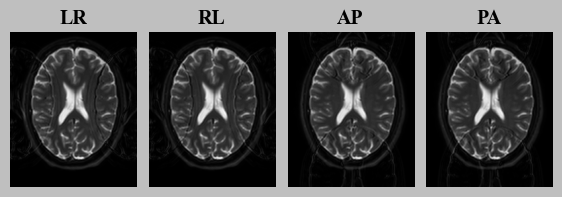

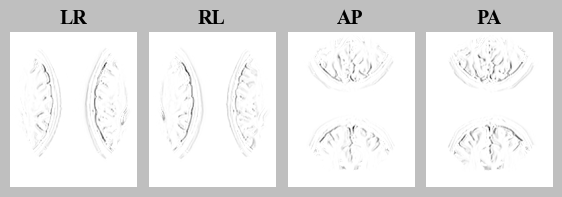

In [9]:
f = myPlot.show_imgs_array(APLR_N, list_of_names=['LR', 'RL', 'AP', 'PA'])

# myPlot.save_figure(f, 'GhostedImages')
save_individual_imgs(APLR_N, labels = ['LR', 'RL', 'AP', 'PA'], title_tag=f'GhostImageatR{R_factor}')
temp_imgs =np.abs( APLR_N - APLR_Ns - data[..., np.newaxis])
prt_green('{} {}'.format(np.max(temp_imgs), np.min(temp_imgs)))
f = myPlot.show_imgs_array((np.abs(APLR_N - APLR_Ns)- data[..., np.newaxis]), list_of_names=['LR', 'RL', 'AP', 'PA'], 'test')


In [1]:
# Setting thresholds
thr_vba = 0.26
thr_ssim = 0.9

vba_th = (vba_imgs > thr_vba) * APLR_Ns_prime_Otsu
f = myPlot.show_imgs_array(vba_imgs)
save_individual_imgs(vba_imgs, labels = ['LR', 'RL', 'AP', 'PA'], title_tag=f'VBA_R{R_factor}')
print(mySubject.compute_dice_nd(APLR_Ns_Otsu, vba_th *APLR_Ns_prime_Otsu))
f = myPlot.show_imgs_array(vba_th)
save_individual_imgs(vba_th, labels = ['LR', 'RL', 'AP', 'PA'], title_tag=f'VBA_TH_R{R_factor}')


NameError: name 'vba_imgs' is not defined

 Exist image: C:/Users/thaias/OneDrive - National Institutes of Health/FiguresOfSimulation\individual_fig_LR_GhostImage.png.png
 Exist image: C:/Users/thaias/OneDrive - National Institutes of Health/FiguresOfSimulation\individual_fig_RL_GhostImage.png.png
 Exist image: C:/Users/thaias/OneDrive - National Institutes of Health/FiguresOfSimulation\individual_fig_AP_GhostImage.png.png
 Exist image: C:/Users/thaias/OneDrive - National Institutes of Health/FiguresOfSimulation\individual_fig_PA_GhostImage.png.png
 Exist image: C:/Users/thaias/OneDrive - National Institutes of Health/FiguresOfSimulation\Actual Ghost.png
 Exist image: C:/Users/thaias/OneDrive - National Institutes of Health/FiguresOfSimulation\Actual Ghost Masked.png
 Exist image: C:/Users/thaias/OneDrive - National Institutes of Health/FiguresOfSimulation\Synthetic Ghost.png
 Exist image: C:/Users/thaias/OneDrive - National Institutes of Health/FiguresOfSimulation\Synthetic Ghost Masked.png


'C:/Users/thaias/OneDrive - National Institutes of Health/FiguresOfSimulation\\Synthetic Ghost Masked.png'

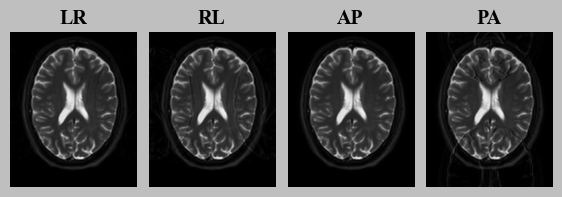

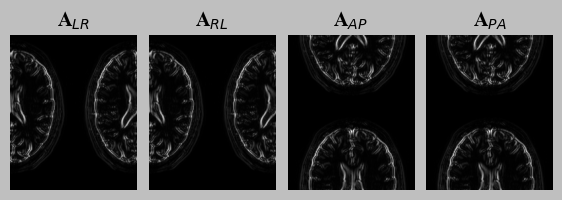

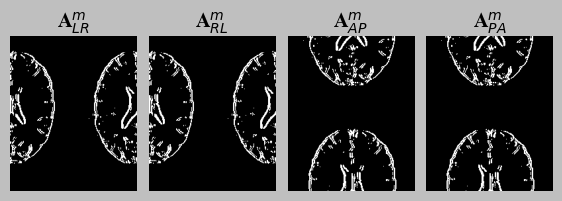

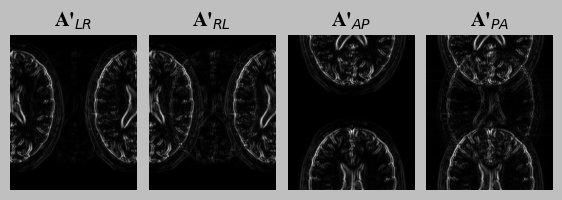

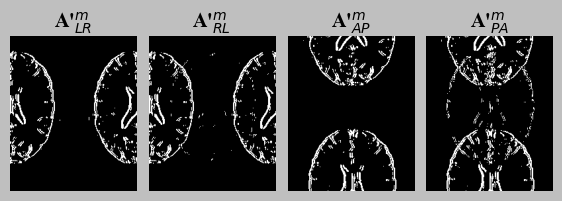

In [11]:
f = myPlot.show_imgs_array(APLR_N, list_of_names=['LR', 'RL', 'AP', 'PA'])
# myPlot.save_figure(f, 'GhostedImages')
save_individual_imgs(APLR_N, labels = ['LR', 'RL', 'AP', 'PA'], title_tag='GhostImage')

f = myPlot.show_imgs_array(APLR_Ns, list_of_names=['A$_{LR}$', 'A$_{RL}$', 'A$_{AP}$', 'A$_{PA}$'])

myPlot.save_figure(f, 'Actual Ghost')

f = myPlot.show_imgs_array(APLR_Ns_Otsu, list_of_names=['A$^{m}_{LR}$', 'A$^{m}_{RL}$', 'A$^{m}_{AP}$', 'A$^{m}_{PA}$'])

myPlot.save_figure(f, 'Actual Ghost Masked')
f = myPlot.show_imgs_array(APLR_N_prime,  list_of_names=['A\'$_{LR}$', 'A\'$_{RL}$', 'A\'$_{AP}$', 'A\'$_{PA}$'])
myPlot.save_figure(f, 'Synthetic Ghost')

f = myPlot.show_imgs_array(APLR_Ns_prime_Otsu,list_of_names=['A\'$^{m}_{LR}$', 'A\'$^{m}_{RL}$', 'A\'$^{m}_{AP}$', 'A\'$^{m}_{PA}$'])
myPlot.save_figure(f, 'Synthetic Ghost Masked')

# f = myPlot.show_imgs_array(APLR_Ns_prime_Otsu, list_of_names=ped_str)

 SAVING image to C:/Users/thaias/OneDrive - National Institutes of Health/Figures\GhostedImages_bm_R[[9.62124913e-01 1.22922460e+01 2.19583582e+01 ... 5.83005586e+00
  1.06786963e+00 6.63448506e-01]
 [9.91072683e+00 1.77439162e+01 2.77760481e+01 ... 1.25307585e+01
  1.27414316e+00 1.82338252e+00]
 [1.24559297e+01 1.55375897e+01 2.30319070e+01 ... 1.16211366e+01
  7.70156459e+00 4.90675956e+00]
 ...
 [9.50960550e-13 2.97953732e-12 2.11311864e-12 ... 1.98378588e-12
  2.93777633e-12 3.88520967e-12]
 [2.83293736e-12 5.20130230e-12 1.23833589e-12 ... 1.77636774e-12
  3.26246755e-12 3.39733845e-12]
 [1.96677054e-12 1.85979911e-12 3.21733195e-12 ... 1.72138976e-12
  3.21556357e-12 2.13437268e-12]].png


FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/thaias/OneDrive - National Institutes of Health/Figures\\GhostedImages_bm_R[[9.62124913e-01 1.22922460e+01 2.19583582e+01 ... 5.83005586e+00\n  1.06786963e+00 6.63448506e-01]\n [9.91072683e+00 1.77439162e+01 2.77760481e+01 ... 1.25307585e+01\n  1.27414316e+00 1.82338252e+00]\n [1.24559297e+01 1.55375897e+01 2.30319070e+01 ... 1.16211366e+01\n  7.70156459e+00 4.90675956e+00]\n ...\n [9.50960550e-13 2.97953732e-12 2.11311864e-12 ... 1.98378588e-12\n  2.93777633e-12 3.88520967e-12]\n [2.83293736e-12 5.20130230e-12 1.23833589e-12 ... 1.77636774e-12\n  3.26246755e-12 3.39733845e-12]\n [1.96677054e-12 1.85979911e-12 3.21733195e-12 ... 1.72138976e-12\n  3.21556357e-12 2.13437268e-12]].png'

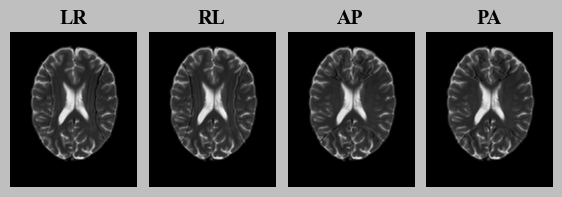

In [27]:
mask_nan = mask.copy()
mask_nan[mask ==0] = np.nan


In [28]:
ssim_imgs = np.squeeze(np.stack([mySubject.compare_ssim_2D(APLR_N[...,i], data,win_size=3,normalize=True, full=True)[1] for i in range(4)], axis = -1))
ssim_imgs_nan = ssim_imgs*mask_nan[...,np.newaxis]
ssim_imgs_th = (ssim_imgs < thr_ssim)*mask[...,np.newaxis]
# f = myPlot.show_imgs_array(ssim_imgs_th)

In [29]:
# f = myPlot.show_imgs_array((ssim_imgs< thr_ssim)*mask[...,np.newaxis])
# f = myPlot.show_imgs_array((ssim_imgs< thr_ssim))
# prt_cyan(np.nanmean(ssim_imgs_nan, axis=  (0,1)))
# f = myPlot.show_imgs_array((ssim_imgs< thr_ssim)*mask[...,np.newaxis] *APLR_Ns_Otsu)
# myPlot.save_figure(f, 'ssim_artdetection_n2')


In [30]:
# f = myPlot.show_imgs_array(vba_imgs)


[0.7213240954580447, 0.7089147286821705, 0.7328436516264428, 0.7406015037593985]


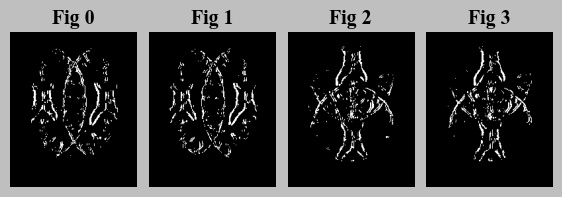

[0.403004403004403, 0.3970780067831985, 0.4397575757575758, 0.4622754491017964]
[0.9501915708812261, 0.9467325645249862, 0.8779324055666005, 0.8730031948881789]
[0.8507795100222717, 0.8555304740406321, 0.7511057498994773, 0.800625488663018]


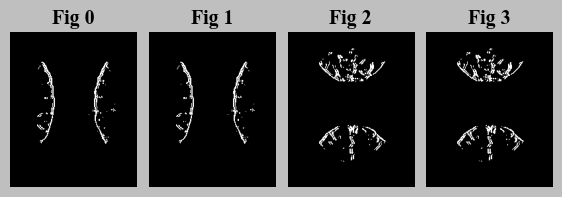

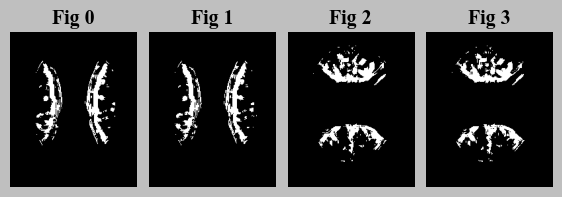

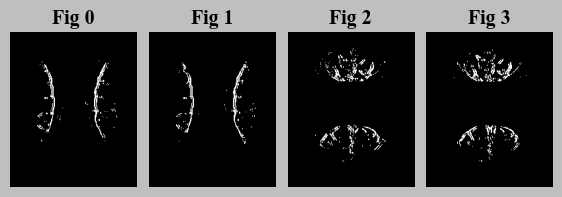

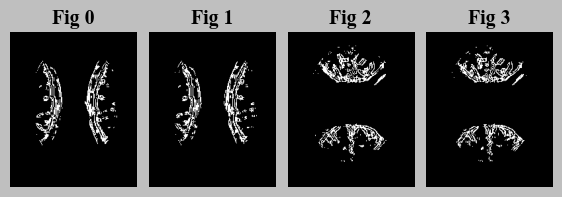

In [14]:
print(mySubject.compute_dice_nd(vba_th, ssim_imgs_th))
print(mySubject.compute_dice_nd(APLR_Ns_Otsu*mask[...,np.newaxis], ssim_imgs_th *APLR_Ns_Otsu))
print(mySubject.compute_dice_nd(APLR_Ns_Otsu*mask[...,np.newaxis], vba_th *APLR_Ns_prime_Otsu))

delta_ssim_vba = vba_th - ssim_imgs_th
f = myPlot.show_imgs_array(APLR_Ns_Otsu*mask[...,np.newaxis])
f = myPlot.show_imgs_array(ssim_imgs_th)
f = myPlot.show_imgs_array(vba_th)
f = myPlot.show_imgs_array(np.abs(vba_th - ssim_imgs_th))


In [102]:
print(DICE_COE(vba_th, ssim_imgs_th))
print(DICE_COE(APLR_Ns_Otsu*mask[...,np.newaxis], ssim_imgs_th))
print(DICE_COE(APLR_Ns_Otsu*mask[...,np.newaxis], vba_th))

0.279
0.437
0.355


In [117]:
print(mySubject.compute_dice_nd((vba_imgs*mask[...,np.newaxis]*APLR_Ns_Otsu>thr_vba), APLR_Ns_Otsu*mask[...,np.newaxis]>0))
print(mySubject.compute_dice_nd((ssim_imgs*APLR_Ns_Otsu*mask[...,np.newaxis]< thr_ssim),APLR_Ns_Otsu*mask[...,np.newaxis]>0))
# f = myPlot.show_imgs_array(APLR_Ns_prime_Otsu*mask[...,np.newaxis])
# print(np.unique(APLR_Ns_prime_Otsu))

[0.06733444629938787, 0.07631874298540965, 0.11409395973154363, 0.08247027234369006]
[0.96240796881767, 0.9626629705028804, 0.9524301964839711, 0.9528930072190497]


In [79]:
print(mySubject.compute_dice_nd((vba_imgs> thr_vba), (ssim_imgs< thr_ssim)))


[0.48999782561426397, 0.4847994825355757, 0.5169338451117633, 0.51621591291662]


In [118]:
mySubject.compute_dice_nd(vba_imgs*APLR_Ns_prime_Otsu > thr_vba, ssim_imgs*APLR_Ns_prime_Otsu< thr_ssim)


[0.8915708649726382,
 0.8909576158098749,
 0.9006277263538675,
 0.8973452834607115]

In [119]:
mySubject.compute_dice_nd(vba_imgs*APLR_Ns_Otsu*mask[..., np.newaxis] > thr_vba, ssim_imgs*APLR_Ns_Otsu * mask[...,np.newaxis]< thr_ssim)


[0.9660001302677002,
 0.9665928146313915,
 0.9601534892795976,
 0.9569170816193981]

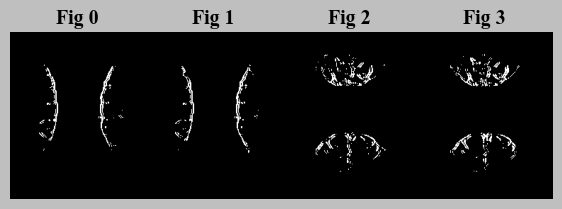

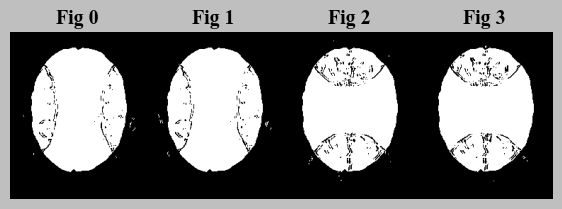

In [81]:
f = myPlot.show_imgs_array(vba_imgs*APLR_Ns_Otsu*mask[..., np.newaxis] > thr_vba)
f = myPlot.show_imgs_array(ssim_imgs*APLR_Ns_Otsu<thr_ssim * mask[...,np.newaxis])